# 02. Benchmark: Math Reasoning


- Date: 2026-05-05
- Status: draft


In [1]:
#| hide-code

from __future__ import annotations

import importlib.util
from pathlib import Path
from types import ModuleType

import matplotlib.pyplot as plt
import pandas as pd


def _find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "python_modules").exists() and (candidate / "extra_docs").exists():
            return candidate
    raise RuntimeError("Failed to locate project root.")


def _load_module(path: Path, name: str) -> ModuleType:
    spec = importlib.util.spec_from_file_location(name, path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Failed to load module: {path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)  # type: ignore[attr-defined]
    return module


PROJECT_ROOT = _find_project_root()
ARTIFACTS_EXAMPLES = PROJECT_ROOT / "artifacts" / "workflow_auto_assembler" / "examples"
STORAGE_PATH = PROJECT_ROOT / "temp" / "math_workflows"

math_tasks_module = _load_module(ARTIFACTS_EXAMPLES / "math_test_examples.py", "math_tasks_artifact")
analysis_module = _load_module(ARTIFACTS_EXAMPLES / "saved_workflow_analysis.py", "saved_workflow_analysis_artifact")

TASK_SPECS = math_tasks_module.task_specs
TASK_DESCRIPTION_TO_ID = {spec["description"]: task_id for task_id, spec in TASK_SPECS.items()}

analysis = analysis_module.analyze_saved_workflows(storage_path=STORAGE_PATH)
analysis_frames = analysis_module.to_dataframes(analysis)
records_df = analysis_frames["records"].copy()
records_df["task_id"] = records_df["task_description"].map(TASK_DESCRIPTION_TO_ID)
records_df["workflow_step_count"] = pd.to_numeric(records_df.get("workflow_step_count"), errors="coerce")
records_df["test_retries"] = pd.to_numeric(records_df.get("test_retries"), errors="coerce")
benchmark_records_df = records_df[records_df["task_id"].notna()].copy()
benchmark_records_df["task_id"] = benchmark_records_df["task_id"].astype(str)

summary_df = (
    benchmark_records_df.groupby("task_id")
    .agg(
        runs=("task_id", "size"),
        completed_runs=("workflow_completed", lambda s: int(pd.Series(s).fillna(False).sum())),
        avg_test_retries=("test_retries", "mean"),
        avg_workflow_steps=("workflow_step_count", "mean"),
        latest_saved_at=("saved_at", "max"),
    )
    .reset_index()
)
summary_df["success_rate"] = summary_df["completed_runs"] / summary_df["runs"]
summary_df["avg_test_retries"] = summary_df["avg_test_retries"].round(2)
summary_df["avg_workflow_steps"] = summary_df["avg_workflow_steps"].round(1)

headline_metrics = {
    "runs": int(len(benchmark_records_df)),
    "completed_runs": int(benchmark_records_df["workflow_completed"].fillna(False).sum()),
    "task_count": int(summary_df["task_id"].nunique()),
    "tasks_solved_once": int((summary_df["completed_runs"] > 0).sum()),
}
headline_metrics


{'runs': 75, 'completed_runs': 74, 'task_count': 15, 'tasks_solved_once': 15}

## Intro

This benchmark tests WAA on deterministic math tasks where the difficulty comes from workflow synthesis rather than ambiguous answers. The useful question is whether WAA can consistently assemble and reuse the right workflow for a small but varied math task set.


## Benchmark Cases

The benchmark cases fall into four small groups:

- **Direct arithmetic**: tasks where one tool or one obvious two-step workflow should be enough.
- **Compositional arithmetic**: tasks that require combining several primitive tools in a fixed order.
- **Symbolic calculus and trigonometry**: tasks that depend on derivative or trig identities.
- **Stress cases**: tasks where the planner has to reconstruct a familiar formula from the available tool set.

One small caveat is worth calling out. `task_8` (`sin(x)^2 + cos(x)^2`) has the same expected output for every input because the identity always evaluates to `1`. That makes it useful as an identity-recognition case, but weak as a pure composition test: a degenerate workflow that returns a constant can still pass numerically.


In [2]:
#| hide-code

TASK_KINDS = {
    "task_1": "Direct arithmetic",
    "task_2": "Direct arithmetic",
    "task_3": "Direct arithmetic",
    "task_4": "Direct arithmetic",
    "task_5": "Compositional arithmetic",
    "task_6": "Compositional arithmetic",
    "task_7": "Compositional arithmetic",
    "task_8": "Symbolic calculus and trigonometry",
    "task_9": "Compositional arithmetic",
    "task_10": "Symbolic calculus and trigonometry",
    "task_11": "Symbolic calculus and trigonometry",
    "task_12": "Stress cases",
    "task_13": "Compositional arithmetic",
    "task_14": "Compositional arithmetic",
    "task_15": "Symbolic calculus and trigonometry",
}


def render_task_group(kind: str):
    for task_id in [tid for tid, task_kind in TASK_KINDS.items() if task_kind == kind]:
        spec = TASK_SPECS[task_id]
        tests = math_tasks_module.task_tests[task_id]
        rows = []
        for idx, (inputs, outputs) in enumerate(zip(tests["inputs"], tests["expected_outputs"]), start=1):
            row = {"case": idx}
            row.update(inputs.model_dump())
            row.update({f"output_{key}": value for key, value in outputs.model_dump().items()})
            rows.append(row)

        print(task_id)
        print(spec["description"])
        display(pd.DataFrame(rows))


### Direct Arithmetic


In [3]:
#| hide-code

render_task_group("Direct arithmetic")


task_1
Add left and right and return the result as a single scalar value.


,case,left,right,output_value
0,1,2.00,5.00,7.0
1,2,-3.00,10.00,7.0
2,3,1.50,2.50,4.0
3,4,0.00,7.00,7.0
4,5,-8.00,-2.00,-10.0
5,6,9.00,1.00,10.0
6,7,100.00,0.50,100.5
7,8,12.00,-2.00,10.0
8,9,3.25,4.75,8.0
9,10,-1.25,1.25,0.0


task_2
Subtract right from left and return the difference.


,case,left,right,output_value
0,1,7.00,2.00,5.0
1,2,5.00,5.00,0.0
2,3,-4.00,3.00,-7.0
3,4,9.50,1.50,8.0
4,5,0.00,2.00,-2.0
5,6,20.00,-2.00,22.0
6,7,-8.00,-3.00,-5.0
7,8,4.25,0.25,4.0
8,9,3.00,9.00,-6.0
9,10,100.00,33.00,67.0


task_3
Multiply left and right and return the product.


,case,left,right,output_value
0,1,3.0,4.0,12.00
1,2,-2.0,5.0,-10.00
2,3,1.5,2.0,3.00
3,4,0.0,10.0,0.00
4,5,-3.0,-7.0,21.00
5,6,8.0,0.5,4.00
6,7,12.0,3.0,36.00
7,8,9.0,-1.0,-9.00
8,9,2.5,2.5,6.25
9,10,11.0,11.0,121.00


task_4
Divide left by right and return the quotient.


,case,left,right,output_value
0,1,8.0,2.0,4.00
1,2,9.0,3.0,3.00
2,3,7.5,2.5,3.00
3,4,-12.0,4.0,-3.00
4,5,1.0,4.0,0.25
5,6,100.0,5.0,20.00
6,7,-9.0,-3.0,3.00
7,8,3.6,1.2,3.00
8,9,22.0,11.0,2.00
9,10,81.0,9.0,9.00


### Compositional Arithmetic


In [4]:
#| hide-code

render_task_group("Compositional arithmetic")


task_5
First add left and right, then square the result.


,case,left,right,output_value
0,1,2.00,3.00,25.0
1,2,-1.00,4.00,9.0
2,3,1.50,0.50,4.0
3,4,0.00,7.00,49.0
4,5,-4.00,-2.00,36.0
5,6,10.00,-1.00,81.0
6,7,6.00,6.00,144.0
7,8,3.25,1.75,25.0
8,9,-8.00,9.00,1.0
9,10,0.50,0.50,1.0


task_6
Compute (left + right) multiplied by (left - right).


,case,left,right,output_value
0,1,7.0,2.00,45.0000
1,2,5.0,5.00,0.0000
2,3,8.0,3.00,55.0000
3,4,1.5,0.50,2.0000
4,5,-4.0,2.00,12.0000
5,6,10.0,-1.00,99.0000
6,7,3.0,1.00,8.0000
7,8,12.0,4.00,128.0000
8,9,0.5,0.25,0.1875
9,10,-6.0,-2.00,32.0000


task_7
Return the distance between the two numbers on the real line.


...

,case,left,right,output_value
0,1,4.00,9.0,6.0
1,2,1.00,16.0,4.0
2,3,2.25,4.0,3.0
3,4,3.00,12.0,6.0
4,5,0.25,4.0,1.0
5,6,6.00,24.0,12.0
6,7,5.00,20.0,10.0
7,8,1.50,6.0,3.0
8,9,10.00,40.0,20.0
9,10,2.00,8.0,4.0


task_13
Compute the normalized radius sqrt(a squared plus b squared) divided by the magnitude of c.


,case,a,b,c,output_value
0,1,3.0,4.0,-2.0,2.5
1,2,5.0,12.0,13.0,1.0
2,3,8.0,15.0,-5.0,3.4
3,4,6.0,8.0,10.0,1.0
4,5,1.5,2.0,-0.5,5.0
5,6,7.0,24.0,5.0,5.0
6,7,9.0,12.0,-3.0,5.0
7,8,4.0,3.0,2.5,2.0
8,9,10.0,24.0,-2.0,13.0
9,10,0.6,0.8,0.5,2.0


task_14
Build a cubic interaction score by adding a and b, cubing the result, and dividing by the magnitude of c.


,case,a,b,c,output_value
0,1,1.0,2.0,-3.0,9.0
1,2,2.0,1.0,9.0,3.0
2,3,3.0,3.0,-6.0,36.0
3,4,0.5,1.5,2.0,4.0
4,5,-1.0,4.0,-3.0,9.0
5,6,5.0,-2.0,3.0,9.0
6,7,2.5,2.5,-5.0,25.0
7,8,4.0,1.0,2.5,50.0
8,9,6.0,-3.0,-9.0,3.0
9,10,1.2,0.8,0.5,16.0


### Symbolic Calculus and Trigonometry


In [5]:
#| hide-code

render_task_group("Symbolic calculus and trigonometry")


task_8
Compute sin(x)^2 plus cos(x)^2 for the provided x.


,case,x,output_value
0,1,0.000000,1.0
1,2,0.500000,1.0
2,3,1.200000,1.0
3,4,-0.700000,1.0
4,5,2.400000,1.0
5,6,1.047198,1.0
6,7,1.570796,1.0
7,8,3.000000,1.0
8,9,-2.500000,1.0
9,10,4.100000,1.0


task_10
Return the derivative of x squared evaluated at x.


,case,x,output_value
0,1,4.00,8.0
1,2,-1.50,-3.0
2,3,0.00,0.0
3,4,2.25,4.5
4,5,-3.00,-6.0
5,6,7.00,14.0
6,7,0.50,1.0
7,8,-8.00,-16.0
8,9,10.00,20.0
9,10,1.20,2.4


task_11
Return the derivative of x cubed plus sine of x evaluated at x.


,case,x,output_value
0,1,2.000000,11.583853
1,2,0.000000,1.000000
2,3,-1.000000,3.540302
3,4,1.500000,6.820737
4,5,1.570796,7.402203
5,6,-2.500000,17.948856
6,7,3.000000,26.010008
7,8,0.250000,1.156412
8,9,-4.000000,47.346356
9,10,5.000000,75.283662


task_15
Compute tangent of x by dividing sine of x by cosine of x.


,case,x,output_value
0,1,0.25,0.255342
1,2,0.50,0.546302
2,3,1.00,1.557408
3,4,-0.75,-0.931596
4,5,1.20,2.572152
5,6,-1.10,-1.964760
6,7,0.90,1.260158
7,8,-0.30,-0.309336
8,9,0.70,0.842288
9,10,-0.60,-0.684137


### Stress Cases


In [6]:
#| hide-code

render_task_group("Stress cases")


task_12
Multiply two positive numbers, but do it through logarithms and exponentiation rather than a direct multiply tool.


,case,left,right,output_value
0,1,2.00,8.0,16.0
1,2,1.50,4.0,6.0
2,3,3.00,9.0,27.0
3,4,0.50,6.0,3.0
4,5,10.00,2.0,20.0
5,6,4.00,4.0,16.0
6,7,1.25,8.0,10.0
7,8,7.00,3.0,21.0
8,9,2.50,2.0,5.0
9,10,12.00,0.5,6.0


## Results

The results below come from the benchmark run documented in this note. Each task was run five times. The most useful metrics here are how many reruns completed, how much retry pressure each task needed, and how large the resulting workflows were.

The workflow artifacts used in this note do not currently persist wall-clock runtime, so this section uses saved retry counts instead of average duration.


In [7]:
#| hide-code

results_table = summary_df[["task_id", "runs", "completed_runs", "success_rate", "avg_test_retries", "avg_workflow_steps"]].sort_values("task_id")
results_table


,task_id,runs,completed_runs,success_rate,avg_test_retries,avg_workflow_steps
0,task_1,5,5,1.0,0.0,2.0
1,task_10,5,5,1.0,0.0,2.0
2,task_11,5,5,1.0,0.0,4.4
3,task_12,5,5,1.0,1.2,5.0
4,task_13,5,5,1.0,1.6,7.0
5,task_14,5,5,1.0,0.0,5.0
6,task_15,5,5,1.0,0.0,4.0
7,task_2,5,5,1.0,0.0,2.0
8,task_3,5,5,1.0,0.0,2.0
9,task_4,5,5,1.0,0.0,2.0


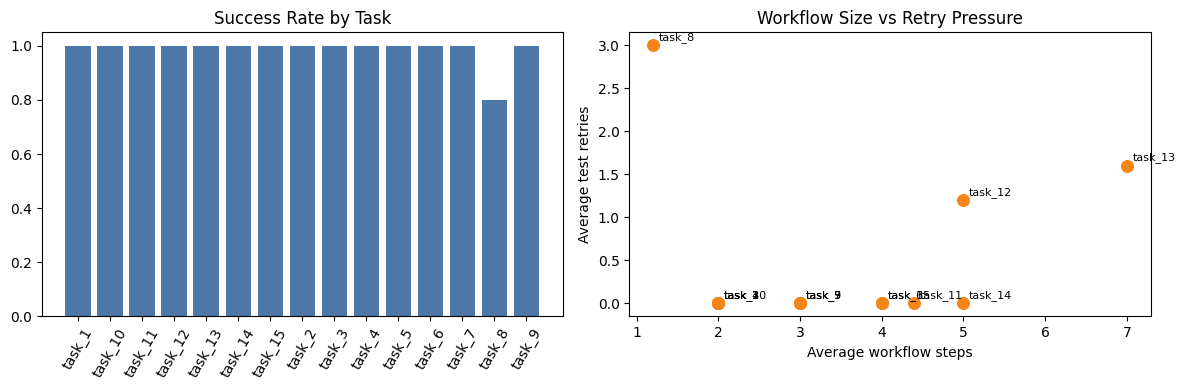

In [8]:
#| hide-code

plot_df = summary_df.sort_values("task_id").copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(plot_df["task_id"].astype(str), plot_df["success_rate"], color="#4C78A8")
axes[0].set_title("Success Rate by Task")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=60)

axes[1].scatter(plot_df["avg_workflow_steps"], plot_df["avg_test_retries"], color="#F58518", s=70)
for _, row in plot_df.iterrows():
    axes[1].annotate(str(row["task_id"]), (row["avg_workflow_steps"], row["avg_test_retries"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
axes[1].set_title("Workflow Size vs Retry Pressure")
axes[1].set_xlabel("Average workflow steps")
axes[1].set_ylabel("Average test retries")

plt.tight_layout()
plt.show()


## Example Workflows

A few saved workflows are worth showing directly. One from each group and one exception worth noting. 


In [9]:
#| hide-code

example_task_ids = ["task_1", "task_7", "task_8", "task_11", "task_12"]
example_records = []

for task_id in example_task_ids:
    task_records = benchmark_records_df[(benchmark_records_df["task_id"] == task_id) & (benchmark_records_df["workflow_completed"] == True)].sort_values("saved_at", ascending=False)
    if task_records.empty:
        continue
    record = task_records.iloc[0].to_dict()
    record["group"] = TASK_KINDS.get(task_id) if task_id != "task_8" else "Exception"
    example_records.append(record)

pd.DataFrame(example_records)[["task_id", "group", "workflow_id", "workflow_step_count", "test_retries"]] if example_records else "No completed example workflows found."


,task_id,group,workflow_id,workflow_step_count,test_retries
0,task_1,Direct arithmetic,9d418c7863d543959ae985642cbad0bb,2,0
1,task_7,Compositional arithmetic,de5ac14d307940c99e97321f9b9e705a,3,0
2,task_8,Exception,ff62880d4d93476fab5bb81802081a91,2,3
3,task_11,Symbolic calculus and trigonometry,b4ef5b22b358428f9582b51622c88a98,4,0
4,task_12,Stress cases,a9eb4705d55b4cceaa691a927e0a935f,5,0


In [10]:
#| hide-code

import json

for record in example_records:
    print(f"{record['task_id']}: {record['task_description']}")
    matching = analysis_module.load_saved_workflows(storage_path=STORAGE_PATH, input_ids=[record["input_id"]])
    workflow_object = next((item for item in matching if item.get("id") == record["workflow_id"]), None)
    if workflow_object is None:
        print("Missing saved workflow")
        print()
        continue

    for step in workflow_object.get("workflow") or []:
        print(f"  {step['id']}. {step['name']}")
        args = step.get("args") or {}
        if args:
            print(json.dumps(args, indent=4))
        else:
            print("{}")
    print()


task_1: Add left and right and return the result as a single scalar value.
  1. add
{
    "left": "0.output.left",
    "right": "0.output.right"
}
  2. output_model
{
    "value": "1.output.value"
}

task_7: Return the distance between the two numbers on the real line.
  1. subtract
{
    "left": "0.output.left",
    "right": "0.output.right"
}
  2. absolute_value
{
    "x": "1.output.value"
}
  3. output_model
{
    "value": "2.output.value"
}

task_8: Compute sin(x)^2 plus cos(x)^2 for the provided x.
  1. divide
{
    "left": "1",
    "right": "1"
}
  2. output_model
{
    "value": "1.output.value"
}

task_11: Return the derivative of x cubed plus sine of x evaluated at x.
  1. derivative_cube
{
    "x": "0.output.x"
}
  2. derivative_sine
{
    "x": "0.output.x"
}
  3. add
{
    "left": "1.output.value",
    "right": "2.output.value"
}
  4. output_model
{
    "value": "3.output.value"
}

task_12: Multiply two positive numbers, but do it through logarithms and exponentiation rather 

## Conclusion

In this benchmark, all 15 tasks were run 5 times. 14 tasks completed in all 5 runs. `task_8` completed in 4 of 5 runs and remains the main exception in this set.

`task_8` is also defined in a way that lets the system in its current form exploit the test. Because all expected outputs are identical, the system can fill in the final answer directly instead of building the intended trig workflow. The numeric output is not necessarily wrong, but it is not the behavior this task was meant to reward.

This benchmark shows that, for this system, workflow composition is easier to trust when more than one test case is provided and the expected outputs vary across those cases. When every expected output is identical, a shortcut or overfitted answer may pass.
